## 이상값 개념과 탐색

### 이상값이란?
- 데이터셋에서 다른 값들과 현저히 다른 극단적인 값 
- 오류, 측정 문제, 극단적인 특성 등의 원인으로 발생
- 분석, 시각화, 모델링에 왜곡 또는 노이즈를 일으킬 수 있음


In [5]:
import pandas as pd

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Hannah', 'lan', 'Judy'],
    'Salary': [3200, 3400, 3100, 8000, 3300, 3600, 15500, 3000, 3400, 9500],
    'Age': [25, 28, 26, 27, 29, 30, 26, 31, 32, 28]
}

df = pd.DataFrame(data)
df

,Name,Salary,Age
0,Alice,3200,25
1,Bob,3400,28
2,Charlie,3100,26
3,David,8000,27
4,Eve,3300,29
5,Frank,3600,30
6,Grace,15500,26
7,Hannah,3000,31
8,lan,3400,32
9,Judy,9500,28


#### 1. IQR 기준 탐색
- IQR (Inter Quartile Range: 사분위수 사위의 범위)
- IQR: Q3(75%) - Q1(25%) 
- 기준; Q1 - 1.51IQR 미만 또는 Q3 + 1.5IQR 초과

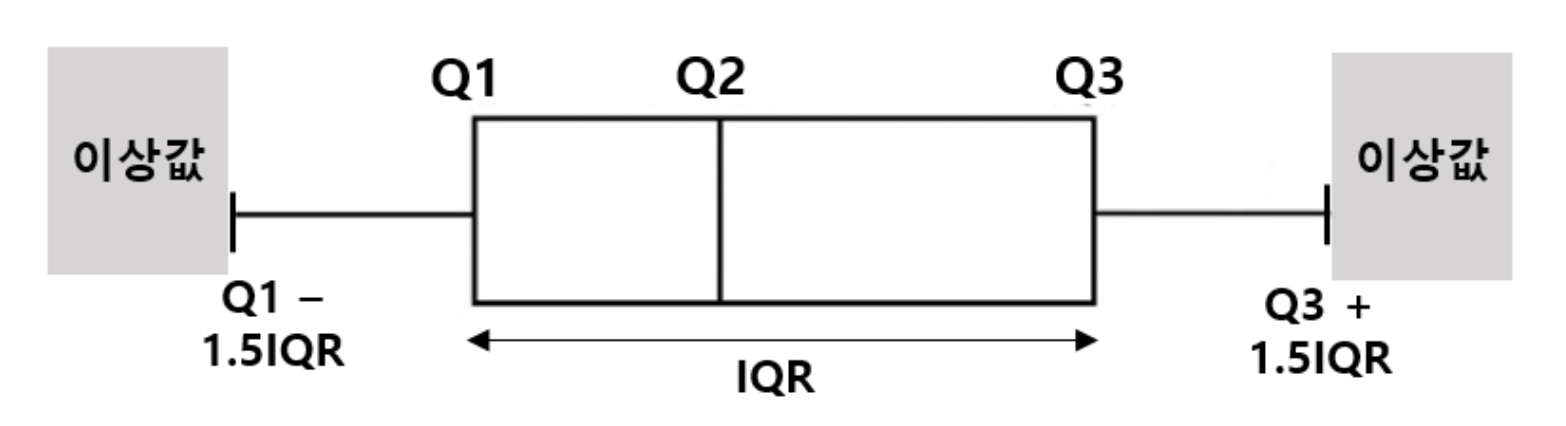


> #### quantile() 함수
> - quantile() 함수는 주어진 Series나 DataFrame의 분위수(quantile)를 계산하는 함수
> - 분위수는 데이터를 작은 값부터 정렬했을 때 일정 비율에 해당하는 값을 의미
> - 예) 0.25 분위수(Q1), 0.5분위수(Q2=중앙값), 0.75 분위수 (Q3)

In [7]:
data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
s = pd.Series(data)

print(s.quantile(.25)) #Q1
print(s.quantile(0.5)) #Q2
print(s.quantile(.75)) #Q3

32.5
55.0
77.5


In [8]:
q1 = df['Salary'].quantile(0.25) #quantile(데이터를 크기 순서대로 정렬한 뒤, 특정 비율에 위치하는 값을 반환하는 통계 함수)
q3 = df['Salary'].quantile(0.75)
iqr = q3 - q1

outliers = (df['Salary'] < q1 - 1.5*iqr) | (df['Salary'] > q3 + 1.5*iqr)
df[outliers]

,Name,Salary,Age
6,Grace,15500,26


#### 2. 표준편차 기준 탐색
- 평균 ± 표준편차 기준
- 통상적으로 평균 ± 2~3 표준편차 벗어난 값은 이상값으로 간주
- 표준편차 : 평균을 기준으로 데이터가 얼마나 퍼져있는지에 대한 지표
- `std()`: Standard Deviation (표준, 편차 약자)

In [9]:
mean = df['Salary'].mean()
std = df['Salary'].std()

outliers = (df['Salary'] < mean - 2*std) | (df['Salary'] > mean + 2*std)
df[outliers]

,Name,Salary,Age
6,Grace,15500,26
